# Lab 2: Maze Solving Using BFS, DFS, and A* Search

## Fundamentals of Artificial Intelligence

**Name:** Ando, Mark John S
**Course:** BSCSAI
**Section:** 2A  
**Date:** August 21, 2026
**GitHub URL:** https://github.com/mark92233/FUNDAI-Laboratories-09282.git

## Description
This laboratory implements BFS, DFS, and A* Search to solve a maze.
The search results are visualized using matplotlib.




In [54]:
from collections import deque
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Maze Class

The `Maze` Class stores the grid, start position, and goal position
The value `0` represents an open cell
The value `1` represents a wall

In [52]:
class Maze:
  def __init__(self, grid, start, goal):
    self.grid = grid
    self.start = start
    self.goal = goal
    self.rows = len(grid)
    self.cols = len(grid[0]) if self.rows > 0 else 0

  def inside(self, pos):
    r, c = pos
    return 0 <= r < self.rows and 0 <= c < self.cols

  def passable(self, pos):
    if not self.inside(pos):
      return False
    r, c = pos
    return self.grid[r][c] == 0

  def neighbors(self, pos):
    r, c = pos
    directions = [(-1, 0), (1, 0),(0, -1), (0,1)]
    result = []

    for dr, dc in directions:
      nr, nc = r + dr, c + dc
      next_pos=(nr, nc)

      if self.passable(next_pos):
        result.append(next_pos)
    return result

## SearchResult Class

The `SearchResult` class stores the output of each search algorithm.
It includes the algorithm name, success status, path, visisted order, and parent map.

In [53]:
class SearchResult:
  def __init__(self, algorithm, success, path, visited_order, parent, root):
    self.algorithm = algorithm
    self.success = success
    self.path = path
    self. visited_order = visited_order
    self.parent = parent
    self.root = root

    self.path_set = set(path)
    self.visited_set = set(visited_order)

  @property
  def path_length(self):
    return len(self.path)

  @property
  def nodes_expanded(self):
    return len(self.visited_order)

  def summary(self):
    print(f"Algorithm: {self.algorithm}")
    print(f"Success: {self.success}")
    print(f"Path Length: {self.path_length}")
    print(f"Nodes Expanded: {self.nodes_expanded}")
    print(f"Path: {self.path}")
    print("--" * 50)



## SearchSolver Class

The `SearchSolver` Class contains the implementation of BFS, DFS, and A* seach.


In [33]:
class SearchSolver:
  def __init__(self, maze):
    self.maze = maze

  def _reconsturct_path(self, parent, goal):
    path = []
    current = goal

    while current is not None:
      path.append(current)
      current = parent[current]

    path.reverse()
    return path

  def _heuristic(self, a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

  def bfs(self):
    start = self.maze.start
    goal = self.maze.goal
    if not self.maze.passable(start) or not self.maze.passable(goal):
      return SearchResult("BFS", False, [], [], {start: None}, start)

    frontier = deque([start])
    visited = {start}
    parent = {start: None}
    visited_order = []
    success = False

    while frontier:
      current = frontier.popleft()
      visited_order.append(current)

      if current == goal:
        success = True
        break

      for neighbor in self.maze.neighbors(current):
        if neighbor not in visited:
          visited.add(neighbor)
          parent[neighbor] = current
          frontier.append(neighbor)
    path = self._reconsturct_path(parent, goal) if success else []

    return SearchResult (algorithm="BFS", success = success, path = path, visited_order= visited_order, parent = parent, root = start)

  def dfs(self):
    start = self.maze.start
    goal = self.maze.goal

    if not self.maze.passable(start) or not self.maze.passable(goal):
      return SearchResult("DFS", False, [], [], {start: None}, start)

    frontier = [start]
    visited = {start}
    parent = {start: None}
    visited_order = []
    success = False

    while frontier:
      current = frontier.pop()
      visited_order.append(current)

      if current == goal:
        success = True
        break

      for neighbor in reversed(self.maze.neighbors(current)): # Reversed to explore in a consistent order
        if neighbor not in visited:
          visited.add(neighbor)
          parent[neighbor] = current
          frontier.append(neighbor)

    path = self._reconsturct_path(parent, goal) if success else []

    return SearchResult(algorithm="DFS", success=success, path=path, visited_order=visited_order, parent=parent, root=start)

  def astar(self):
    start = self.maze.start
    goal = self.maze.goal

    if not self.maze.passable(start) or not self.maze.passable(goal):
      return SearchResult("A* Search ", False, [], [], {start: None}, start)

    counter = 0
    open_heap = []
    heapq.heappush(open_heap, (0, counter, start))

    g_score = {start: 0}
    parent = {start: None}
    visited = set()
    visited_order = []
    success = False

    while open_heap:
      f, _, current = heapq.heappop(open_heap)

      if current in visited:
        continue

      visited.add(current)
      visited_order.append(current)

      if current == goal:
        success = True
        break

      for neighbor in self.maze.neighbors(current):
        tentative_g = g_score[current] + 1

        if tentative_g < g_score.get(neighbor, float('inf')):
          g_score[neighbor] = tentative_g
          f_score = tentative_g + self._heuristic(neighbor, goal)

          parent[neighbor] = current
          counter += 1
          heapq.heappush(open_heap, (f_score, counter, neighbor))

    path = self._reconsturct_path(parent, goal) if success else []

    return SearchResult(algorithm="A* Search", success=success, path=path, visited_order=visited_order, parent=parent, root=start)


## Sample Maze

The maze uses:

- `0` for open cells
-`1` for walls

In [67]:
grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (6, 6)

maze = Maze(grid, start, goal)
solver = SearchSolver(maze)

In [68]:
bfs_result = solver.bfs()
dfs_result = solver.dfs()
astar_result = solver.astar()

bfs_result.summary()
dfs_result.summary()
astar_result.summary()

Algorithm: BFS
Success: True
Path Length: 13
Nodes Expanded: 25
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
----------------------------------------------------------------------------------------------------
Algorithm: DFS
Success: True
Path Length: 21
Nodes Expanded: 21
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (4, 3), (4, 2), (4, 1), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
----------------------------------------------------------------------------------------------------
Algorithm: A* Search
Success: True
Path Length: 13
Nodes Expanded: 21
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
----------------------------------------------------------------------------------------------------


## Visualizaton using matplotlib

The visualization shows:

- Black: Wall
- White: open Cell
- Light blue: visited
- Yellow: final Path
- Green:  Start
- Red: Goal


In [69]:
def visualize_search(maze, result, title = "Search Result") :
  img = np.ones((maze.rows, maze.cols, 3))

  for r  in range(maze.rows):
    for c in range(maze.cols):
      if maze.grid[r][c] == 1:
        img[r,c] = (0.1, 0.1, 0.1)
  if result is not None:
    for r, c in result.visited_set:
      if maze.grid[r][c] == 0:
        img[r, c] = (0.75, 0.87, 1.0)

    for r,c in result.path_set:
      if maze.grid[r][c] == 0:
        img[r][c] = (1.0, 0.85, 0.3)

  img[maze.start] = (0.2, 0.8, 0.2)
  img[maze.goal] = (0.9, 0.2, 0.2)

  plt.figure(figsize = (5,5))
  plt.imshow(img)
  plt.title(title)
  plt.axis("off")
  plt.show()

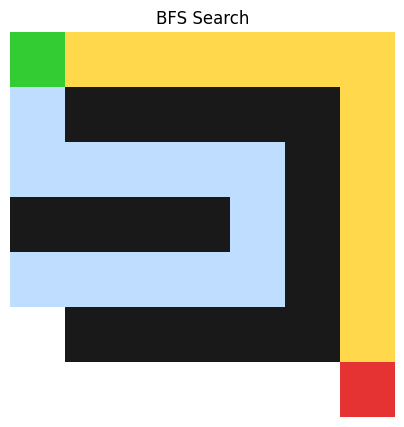

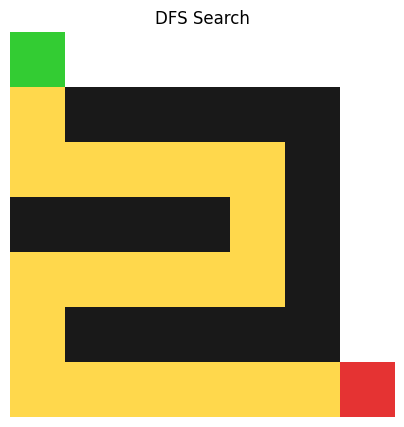

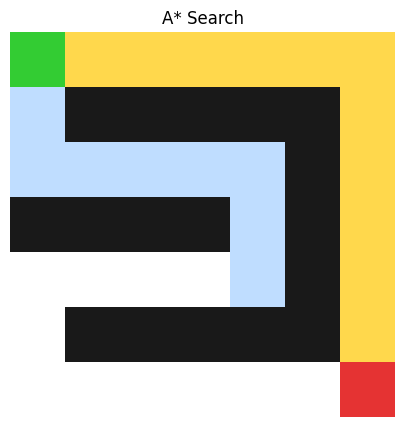

In [70]:
visualize_search(maze, bfs_result, "BFS Search")
visualize_search(maze, dfs_result, "DFS Search")
visualize_search(maze, astar_result, "A* Search")

## Search Tree Documentation

The serach tree is generated from the parent map.
Each child node is connected to its predecessor.


In [75]:
def search_tree_text(result, max_lines=100):
  children = {}

  for child, predecessor in result.parent.items():
    if predecessor is not None:
      if predecessor not in children:
        children[predecessor] = []
      children[predecessor].append(child)

  for node in children:
    children[node].sort()

  lines = []

  def build(node, depth):
    if len(lines) >= max_lines:
      return

    lines.append(" " * depth + str(node))

    for child in children.get(node, []):
      build(child, depth + 1)

  build(result.root, 0)

  if len(lines) >= max_lines:
    lines.append("...search tree truncated for report")
  return "\n".join(lines)

In [76]:
print("BFS Search Tree:")
print(search_tree_text(bfs_result, max_lines=80))

print("\nDFS Search Tree:")
print(search_tree_text(dfs_result, max_lines=80))

print("\nA* Search Tree")
print(search_tree_text(astar_result, max_lines=80))

BFS Search Tree:
(0, 0)
 (0, 1)
  (0, 2)
   (0, 3)
    (0, 4)
     (0, 5)
      (0, 6)
       (1, 6)
        (2, 6)
         (3, 6)
          (4, 6)
           (5, 6)
            (6, 6)
 (1, 0)
  (2, 0)
   (2, 1)
    (2, 2)
     (2, 3)
      (2, 4)
       (3, 4)
        (4, 4)
         (4, 3)
          (4, 2)
           (4, 1)
            (4, 0)
             (5, 0)

DFS Search Tree:
(0, 0)
 (0, 1)
 (1, 0)
  (2, 0)
   (2, 1)
    (2, 2)
     (2, 3)
      (2, 4)
       (3, 4)
        (4, 4)
         (4, 3)
          (4, 2)
           (4, 1)
            (4, 0)
             (5, 0)
              (6, 0)
               (6, 1)
                (6, 2)
                 (6, 3)
                  (6, 4)
                   (6, 5)
                    (6, 6)

A* Search Tree
(0, 0)
 (0, 1)
  (0, 2)
   (0, 3)
    (0, 4)
     (0, 5)
      (0, 6)
       (1, 6)
        (2, 6)
         (3, 6)
          (4, 6)
           (5, 6)
            (6, 6)
 (1, 0)
  (2, 0)
   (2, 1)
    (2, 2)
     (2, 3)
      (2, 4)
 

In [77]:
def expansion_report(result, first_n=20):
  print(f"{result.algorithm} expansion order, first {first_n} nodes:")
  print(result.visited_order[:first_n])
  print("=" * 100)

expansion_report(bfs_result)
expansion_report(dfs_result)
expansion_report(astar_result)

BFS expansion order, first 20 nodes:
[(0, 0), (1, 0), (0, 1), (2, 0), (0, 2), (2, 1), (0, 3), (2, 2), (0, 4), (2, 3), (0, 5), (2, 4), (0, 6), (3, 4), (1, 6), (4, 4), (2, 6), (4, 3), (3, 6), (4, 2)]
DFS expansion order, first 20 nodes:
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (4, 3), (4, 2), (4, 1), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5)]
A* Search expansion order, first 20 nodes:
[(0, 0), (1, 0), (0, 1), (2, 0), (0, 2), (2, 1), (0, 3), (2, 2), (0, 4), (2, 3), (0, 5), (2, 4), (0, 6), (3, 4), (1, 6), (4, 4), (2, 6), (3, 6), (4, 6), (5, 6)]


### BFS
BFS explores the maze level by level. I is useful for finding a shortest path when all move costs are equal.

### DFS
DFS explores one branch deeply before backtracking. It may find a solution quickly, but the path may not be short.

### A*
A* uses both actual cost form the start and estimated cost to the goal. With Manhattan distance, it is often more efficient than BFS.

### Observation
As for my own observation, both the BFS and A* has the same path lenght which they have found the shortest path. Looking at the expanded nodes, A* expanded fewer nodes than BFS (21 vs. 25), indicating that A* is more efficient because it finds the shortest path while doing less work.".

## Guide Questions annd Answers

### 1. Which algorithm fond the shortest path?
**Answer:** Both BFS and A*.

### 2. Which algorithm expanded the fewest nodes?
**Answer:** Both DFS and A*.

### 3. Why is Manhattan distance suitable for this maze?
**Answer:** It restricts the movement of the node by having 4 possible moves only (up, down, left, and right). No diagonal moves are allowed.

### 4. How does the parent map help reconstruct the path?
**Answer:** It helps the algorithm to be guided on what that path leads or if that path was already explored. Like on hiking parent map is the breadcrumb a hiker leaves for him to be guided along the way if he ever comes back to that path if he ends up finding a dead end.

### 5. Why is repeated-state checking important?
**Answer:** Repeated-state acts as a marking on visited path, without markings the algorithm might visit the same path over and over again and might lead to not finding the shortest path or worst case it does not reach the goal at all.


## Reflection

### Challanges Encountered
- Sometimes I write variables and then use them with wrong spelling (example: rows != row)

### What I learned
- I learned about the 3 searching algorihm, BFS, DFS, and A*.
- BFS finds the shortest path but stressed out the work.
- DFS Less work but not the shortest path
- A* it finds the shortest path and uses less work.
- to sum it all up A* is better than the 2 other algorithm as it performs both of them at the same time (keeping the less work and finding the shortest path).